# Basic comparsion of naive and fast convolution

In [1]:
import numpy as np
import sympy as sy
from sympy import Matrix as M 
from matplotlib import pyplot as plt

In [2]:
from sympy.physics.quantum import TensorProduct

In [3]:
from fast_convolution.naive import naive_convolve
from fast_convolution.fast import toomcook_conv1d, toom_cook, g_to_bg
from fast_convolution.utils import plot_pdf, symmetrical_cyclic_convolution

import fast_convolution as fast

In [4]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

Lets do a really basic test to compare naive with fast convolution
The input feature will be a simple 5x5 matrix and the output will be a 3x3 matrix

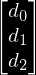

In [5]:
d = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(3))))
d

In [6]:
print(d)

Matrix([[d_0], [d_1], [d_2]])


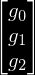

In [7]:
g = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(3))))
g

In [8]:
points = [0, -1, 1, -2, np.inf]
points

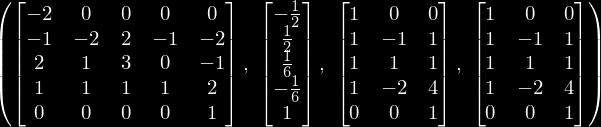

In [9]:
c1, cq1, b1, a1 = toom_cook(3, 3, points)
c1, cq1, b1, a1

In [10]:
print(a1)

Matrix([[1, 0, 0], [1, -1, 1], [1, 1, 1], [1, -2, 4], [0, 0, 1]])


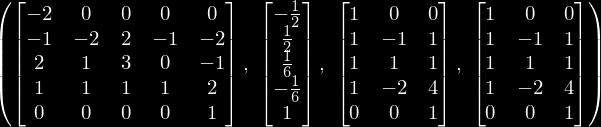

In [11]:
c2, cq2, b2, a2 = toom_cook(3, 3, points)
c2, cq2, b2, a2

Lets try with tensor product

In [24]:
dt = TensorProduct(c1.T, c2.T)
# or #
# dt = TensorProduct(c1, c2).T #
#dt

In [25]:
at = TensorProduct(a1, a2).T
#at

In [26]:
dtd = np.diff(dt, axis=0)
#M(dtd)

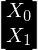

In [15]:
xx = sy.Matrix(sy.symbols(" ".join(f"X_{i}"for i in range(2))))
xx

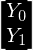

In [16]:
yy = sy.Matrix(sy.symbols(" ".join(f"Y_{i}"for i in range(2))))
yy

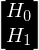

In [17]:
hh = sy.Matrix(sy.symbols(" ".join(f"H_{i}"for i in range(2))))
hh

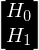

In [18]:
hh = sy.Matrix(sy.symbols(" ".join(f"H_{i}"for i in range(2))))
hh

In [19]:
z = sy.symbols("z^(-2)")
z

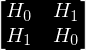

In [20]:
m = [
    [hh[0], hh[1]],
    [hh[1], hh[0]]
]
hhz = sy.Matrix(m)
hhz

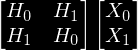

In [21]:
sy.MatMul(hhz, xx, evaluate=False)

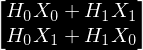

In [22]:
yyz = hhz * xx
yyz

In [27]:
import networkx as nx
graph = nx.DiGraph()

graph.add_edge(xx[0], "*0")
graph.add_edge(xx[1], "*1")
graph.add_edge("*0", hh[1])
graph.add_edge("*1", hh[0])
graph.add_edge(hh[1], '+0')
graph.add_edge(hh[0], '+0')

graph.add_edge(xx[0], "*2")
graph.add_edge(xx[1], "*3")
graph.add_edge("*2", hh[0])
graph.add_edge("*3", hh[1])
graph.add_edge(hh[0], '+1')
graph.add_edge(hh[1], '+1')

#nx.draw_planar(graph, with_labels=True)

In [29]:
from pylatex import (Document, TikZ, TikZNode,
                     TikZDraw, TikZCoordinate,
                     TikZUserPath, TikZOptions)

In [52]:
doc = Document()

# add our sample drawings
with doc.create(TikZ()) as pic:

    # options for our node
    node_kwargs = {'align': 'center',
                   'minimum size': '100pt',
                   'fill': 'black!20'}

    # create our test node

    h1 = TikZNode(
        text='$h_1$', handle='rectangle',
        options=TikZOptions('draw', **node_kwargs)
    )
    pic.append(h1)
    h2 = TikZNode(
        text='$h_1$', handle='rectangle',
        options=TikZOptions('draw',
                            #{'right of': 'h1'},
                            **node_kwargs)
    )
    pic.append(h2)

    # draw a few paths
    pic.append(TikZDraw([TikZCoordinate(0, -6),
                         'rectangle',
                         TikZCoordinate(2, -8)],
                        options=TikZOptions(fill='red')))

    # show use of anchor, relative coordinate
    pic.append(TikZDraw([h1.west,
                         '--',
                         '++(-1,0)']))

doc.generate_pdf('tikzdraw', clean_tex=False)

In [45]:
dir(h1)

['_UserList__cast',
 '__abstractmethods__',
 '__add__',
 '__class__',
 '__class_getitem__',
 '__contains__',
 '__copy__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__mul__',
 '__ne__',
 '__new__',
 '__radd__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__rmul__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_default_escape',
 '_escape',
 '_latex_name',
 '_node_position',
 '_node_text',
 '_possible_anchors',
 '_propagate_packages',
 '_repr_attributes',
 '_repr_attributes_mapping',
 '_repr_attributes_override',
 '_repr_values',
 '_star_latex_name',
 'append',
 'begin_paragraph',
 'clear',
 'content_separator',
 'copy',
 'coun